# Side-Looking SAR Validation: Sentinel-1C

This notebook validates TAT-C's representation of a side-looking synthetic aperture radar (SAR) against the C-band SAR aboard [Sentinel-1C](https://sentiwiki.copernicus.eu/web/s1-mission) of the European Copernicus programme. Sentinel-1 looks to the right of its flight direction. Over land, it mostly operates in the Interferometric Wide swath (IW) mode, a swath about 250 km wide at incidence angles of about 29 to 46 deg, and over sea ice and polar oceans in the Extra Wide swath (EW) mode, about 400 km wide. Sentinel-1A, the first unit, stopped producing data in June 2026; Sentinel-1C (launched in December 2024) and Sentinel-1D now fly the mission.

As in the companion notebook, [Side-Looking SAR Validation: NISAR](ValidateSARNISAR.ipynb), a side-looking instrument in TAT-C is a `PointedInstrument` whose view is rotated rigidly from nadir by a roll angle (negative, for a right-looking radar) with a cross-track field of view spanning the swath, oriented by default relative to the Earth-fixed velocity (`VelocityFrame.EARTH_FIXED`). SAR images are formed in *zero-Doppler* geometry, in which each image line lies in the plane perpendicular to the Earth-fixed velocity, so this default should match. Unlike NISAR, Sentinel-1 also steers its roll angle around the orbit to keep the slant range to the swath nearly constant as the altitude changes ("roll steering"), which a fixed roll angle cannot follow.

The comparison asks five questions:

1. **Orbit.** Does TAT-C's propagation of a public two-line element (TLE) set reproduce Sentinel-1C's position?
2. **Imaging geometry.** What look direction, look angles, and imaging plane do the products describe, and which TAT-C roll angle, field of view, and velocity frame reproduce them?
3. **Swath edges.** How closely do the edges of TAT-C's view match the near-range and far-range edges of the images?
4. **Product footprints.** Does `compute_ground_track` reproduce the footprints of all the products acquired in a day?
5. **Observation times.** Does `collect_observations` predict when Sentinel-1C images a point?

## Reference Data

This notebook uses Level 1 Ground Range Detected (GRD) products from the [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/dataset/sentinel-1-grd), which provides the SAFE products of the Copernicus Sentinel-1 mission with anonymous access (no account required). Each product covers a slice of about 25 s of an acquisition, across the full IW or EW swath. Only its product annotation (an XML file of about 1 MB) is downloaded, which holds:

* the product's mode, pass direction, and first and last line times;
* the spacecraft's Earth-fixed position and velocity (from the restituted orbit) at 10 s intervals; and
* a geolocation grid of 7 lines by 21 samples spanning the image, with the zero-Doppler (azimuth) time, slant range time, geodetic latitude, longitude, and height (on the WGS 84 ellipsoid), and incidence and elevation angles of each point.

All IW and EW products acquired by Sentinel-1C on 2 October 2026 are used (the few Stripmap products, in six different beams, are excluded). The first run downloads about 0.5 GB and takes a few minutes; reduced arrays are cached in a local `data/sentinel1` directory.

Sentinel-1C is modeled with a TLE from [CelesTrak](https://celestrak.org/) whose epoch (2 October 2026, 18:57 UTC) falls within the analysis day.

In [1]:
import concurrent.futures
import json
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "sentinel1"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DAY = datetime(2026, 10, 2, tzinfo=timezone.utc)
STAC = "https://planetarycomputer.microsoft.com/api/stac/v1/search"
TOKEN = "https://planetarycomputer.microsoft.com/api/sas/v1/token/sentinel-1-grd"
TLE = [
    "1 62261U 24235A   26275.78977191 -.00000047  00000+0 -21660-6 0  9997",
    "2 62261  98.1826 281.5711 0001343  90.3841 269.7512 14.59198718 97106",
]
MODES = ["IW", "EW"]

ITEMS_FILE = DATA_DIR / f"s1c_grd_{DAY:%Y%m%d}.json"
if not ITEMS_FILE.exists():
    body = {
        "collections": ["sentinel-1-grd"],
        "datetime": f"{DAY:%Y-%m-%d}T00:00:00Z/{DAY:%Y-%m-%d}T23:59:59Z",
        "limit": 1000,
        "query": {"platform": {"eq": "sentinel-1c"}},
    }
    items, url = [], STAC
    while url:
        page = requests.post(url, json=body, timeout=300).json()
        items += page["features"]
        following = [link for link in page["links"] if link["rel"] == "next"]
        url, body = (following[0]["href"], following[0].get("body", body)) if following else (None, None)
    ITEMS_FILE.write_text(json.dumps(items))
items = [item for item in json.loads(ITEMS_FILE.read_text()) if item["properties"]["sar:instrument_mode"] in MODES]
pd.DataFrame([item["properties"] for item in items]).groupby(["sar:instrument_mode", "sat:orbit_state"]).size().unstack(fill_value=0)

sat:orbit_state,ascending,descending
sar:instrument_mode,,
EW,56,41
IW,169,233


Each product's annotation is downloaded with a shared access signature from the Planetary Computer (which stores it as `annotation/<mode>-<polarization>.xml` within the product) and reduced to its orbit and geolocation grid. Times are converted to seconds since 00:00 UTC on the analysis day.

In [2]:
GRID_FILE = DATA_DIR / f"s1c_grd_annotation_{DAY:%Y%m%d}.npz"


def seconds(text):
    return (pd.Timestamp(text, tz="UTC") - pd.Timestamp(DAY)).total_seconds()


if not GRID_FILE.exists():
    token = requests.get(TOKEN, timeout=60).json()["token"]

    def read_annotation(item):
        base = item["assets"]["safe-manifest"]["href"].rsplit("/", 1)[0]
        mode = item["properties"]["sar:instrument_mode"].lower()
        polarization = item["properties"]["sar:polarizations"][0].lower()
        for attempt in range(5):
            try:
                response = requests.get(f"{base}/annotation/{mode}-{polarization}.xml?{token}", timeout=120)
                response.raise_for_status()
                break
            except requests.RequestException:
                if attempt == 4:
                    raise
        root = ET.fromstring(response.content)
        points = root.findall(".//geolocationGridPoint")
        lines = sorted({int(p.find("line").text) for p in points})
        samples = sorted({int(p.find("pixel").text) for p in points})
        grid = lambda tag, f=float: np.array([f(p.find(tag).text) for p in points]).reshape(len(lines), len(samples))
        orbits = root.findall(".//orbitList/orbit")
        return {
            "id": item["id"],
            "mode": item["properties"]["sar:instrument_mode"],
            "direction": root.find(".//productInformation/pass").text.lower(),
            "time": grid("azimuthTime", seconds),
            "slant_range": grid("slantRangeTime")[0] * 299792458 / 2,
            "lon": grid("longitude"),
            "lat": grid("latitude"),
            "incidence": grid("incidenceAngle"),
            "orbit_time": np.array([seconds(o.find("time").text) for o in orbits]),
            "orbit_position": np.array([[float(o.find(f"position/{c}").text) for c in "xyz"] for o in orbits]),
            "orbit_velocity": np.array([[float(o.find(f"velocity/{c}").text) for c in "xyz"] for o in orbits]),
        }

    with concurrent.futures.ThreadPoolExecutor(16) as pool:
        records = list(pool.map(read_annotation, items))
    np.savez_compressed(
        GRID_FILE,
        id=[r["id"] for r in records],
        mode=[r["mode"] for r in records],
        direction=[r["direction"] for r in records],
        n_line=[len(r["time"]) for r in records],
        n_sample=[r["time"].shape[1] for r in records],
        n_orbit=[len(r["orbit_time"]) for r in records],
        **{k: np.concatenate([r[k].ravel() for r in records]) for k in ["time", "slant_range", "lon", "lat", "incidence"]},
        **{k: np.concatenate([r[k] for r in records]) for k in ["orbit_time", "orbit_position", "orbit_velocity"]},
    )

cache = dict(np.load(GRID_FILE))
size = cache["n_line"] * cache["n_sample"]
cut = lambda key, n: np.split(cache[key], np.cumsum(n)[:-1])
meta = []
for i, (t, sr, lon, lat, inc, ot, op, ov) in enumerate(
    zip(
        cut("time", size), cut("slant_range", cache["n_sample"]), cut("lon", size), cut("lat", size), cut("incidence", size),
        cut("orbit_time", cache["n_orbit"]), cut("orbit_position", cache["n_orbit"]), cut("orbit_velocity", cache["n_orbit"]),
    )
):
    shape2 = (cache["n_line"][i], cache["n_sample"][i])
    # zero-Doppler time of each grid line (the samples of a line differ by microseconds)
    meta.append(
        {
            "look_direction": "Right",
            "time": t.reshape(shape2).mean(axis=1),
            "slant_range": sr,
            "lon": lon.reshape(shape2),
            "lat": lat.reshape(shape2),
            "incidence": inc.reshape(shape2),
            "orbit_time": ot,
            "orbit_position": op,
            "orbit_velocity": ov,
        }
    )


def outline(m):
    """Well-known text of the polygon outlining a product's geolocation grid."""
    ring = [(m["lon"][0, j], m["lat"][0, j]) for j in range(m["lon"].shape[1])]
    ring += [(m["lon"][i, -1], m["lat"][i, -1]) for i in range(1, m["lon"].shape[0])]
    ring += [(m["lon"][-1, j], m["lat"][-1, j]) for j in range(m["lon"].shape[1] - 2, -1, -1)]
    ring += [(m["lon"][i, 0], m["lat"][i, 0]) for i in range(m["lon"].shape[0] - 2, -1, -1)]
    return "POLYGON ((" + ", ".join(f"{x} {y}" for x, y in ring) + "))"


catalog = pd.DataFrame(
    {
        "granule": cache["id"],
        "mode": cache["mode"],
        "direction": cache["direction"],
        "polygon": [outline(m) for m in meta],
        "zero_doppler_start": [str(pd.Timestamp(DAY) + pd.Timedelta(seconds=m["time"][0])) for m in meta],
        "zero_doppler_end": [str(pd.Timestamp(DAY) + pd.Timedelta(seconds=m["time"][-1])) for m in meta],
    }
)
sample = catalog
pd.Series(
    {
        "products": len(catalog),
        "geolocation grid lines": int(cache["n_line"].sum()),
        "orbit state vectors": int(cache["n_orbit"].sum()),
    }
)

products                   499
geolocation grid lines    5994
orbit state vectors       8539
dtype: int64

## Setup

Times in the product metadata count seconds since 00:00 UTC on the analysis day. Helper functions match those of the imager notebooks: Earth-fixed coordinates, horizontal decomposition of offsets along and to the right of a reference direction, and summary statistics.

In [3]:
from datetime import timedelta

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import shapely
import shapely.affinity
import shapely.ops
from pyproj import Geod, Transformer
from shapely.geometry import shape
from shapely.ops import transform as transform_geometry
from skyfield.framelib import itrs

from tatc.analysis import collect_observations, compute_ground_track
from tatc.constants import EARTH_ROTATION_RATE
from tatc.schemas import GeneralPerturbationsOrbit, Point, PointedInstrument, Satellite
from tatc.utils import VelocityFrame, compute_projected_ray_position

GEOD = Geod(ellps="WGS84")
TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
TO_GEODETIC = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
sentinel1 = Satellite(name="Sentinel-1C", orbit=GeneralPerturbationsOrbit.from_tle(TLE))
orbit = sentinel1.orbit.to_gp_orbit()


def to_utc(seconds):
    return [DAY + timedelta(seconds=float(s)) for s in np.atleast_1d(seconds)]


def ecef(lon, lat, height=0.0):
    """Earth-fixed position (m) of geodetic coordinates, stacked on the last axis."""
    return np.stack(TO_ECEF.transform(lon, lat, np.broadcast_to(height, np.shape(lon))), axis=-1)


def up(lon, lat):
    """Geodetic up unit vector, stacked on the last axis."""
    lon, lat = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)


def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def along_right(lon, lat, offset, direction):
    """Components (km) of Earth-fixed offsets along and to the right of the horizontal projection of a direction at a location."""
    u = up(lon, lat)
    along = normalize(direction - np.sum(direction * u, axis=-1, keepdims=True) * u)
    right = np.cross(along, u)
    return np.sum(offset * along, axis=-1) / 1e3, np.sum(offset * right, axis=-1) / 1e3


def interpolate_orbit(m, seconds):
    """Reported Earth-fixed position and velocity, interpolated (cubic Hermite) at times."""
    t, p, v = m["orbit_time"], m["orbit_position"], m["orbit_velocity"]
    k = np.clip(np.searchsorted(t, seconds) - 1, 0, len(t) - 2)
    h = (t[k + 1] - t[k])[:, None]
    s = ((seconds - t[k]) / (t[k + 1] - t[k]))[:, None]
    h00, h10, h01, h11 = 2 * s**3 - 3 * s**2 + 1, s**3 - 2 * s**2 + s, -2 * s**3 + 3 * s**2, s**3 - s**2
    position = h00 * p[k] + h10 * h * v[k] + h01 * p[k + 1] + h11 * h * v[k + 1]
    d00, d10, d01, d11 = (6 * s**2 - 6 * s) / h, 3 * s**2 - 4 * s + 1, (-6 * s**2 + 6 * s) / h, 3 * s**2 - 2 * s
    velocity = d00 * p[k] + d10 * v[k] + d01 * p[k + 1] + d11 * v[k + 1]
    return position, velocity


def inertial_velocity(position, velocity):
    """Inertial velocity expressed in Earth-fixed coordinates."""
    return velocity + EARTH_ROTATION_RATE * np.stack([-position[..., 1], position[..., 0], np.zeros(position.shape[:-1])], axis=-1)


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series({"n": x.size, "median": np.median(x), "p95 |x|": np.percentile(np.abs(x), 95), "max |x|": np.abs(x).max()})


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)

## Test 1: Orbit

TAT-C's propagated position is compared with every orbit state vector in the products, with residuals decomposed along the reported velocity, to its right, and radially, as a function of time before the TLE epoch.

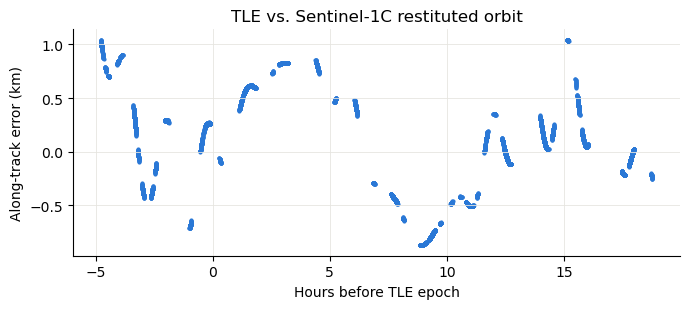

,n,median,p95 |x|,max |x|
along-track (km),8539.0,0.064,0.873,1.044
"cross-track, right (km)",8539.0,0.078,0.290,0.320
radial (km),8539.0,-0.005,0.230,0.301


In [4]:
orbit_time = np.concatenate([m["orbit_time"] for m in meta])
orbit_position = np.concatenate([m["orbit_position"] for m in meta])
orbit_velocity = np.concatenate([m["orbit_velocity"] for m in meta])
p1, v1 = orbit.get_orbit_track(to_utc(orbit_time)).frame_xyz_and_velocity(itrs)
offset1 = np.array(p1.m).T - orbit_position
radial1 = normalize(orbit_position)
along1 = normalize(orbit_velocity - np.sum(orbit_velocity * radial1, axis=-1, keepdims=True) * radial1)
along1_km = np.sum(offset1 * along1, axis=-1) / 1e3
epoch = datetime(2026, 1, 1, tzinfo=timezone.utc) + timedelta(days=float(TLE[0][20:32]) - 1)
hours_before_epoch = (epoch - DAY).total_seconds() / 3600 - orbit_time / 3600
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(hours_before_epoch, along1_km, s=4, color=BLUE)
ax.set(xlabel="Hours before TLE epoch", ylabel="Along-track error (km)", title="TLE vs. Sentinel-1C restituted orbit")
fig.tight_layout()
plt.show()
pd.DataFrame(
    {
        "along-track (km)": summarize(along1_km),
        "cross-track, right (km)": summarize(np.sum(offset1 * np.cross(along1, radial1), axis=-1) / 1e3),
        "radial (km)": summarize(np.sum(offset1 * radial1, axis=-1) / 1e3),
    }
).T.round(3)

The TLE reproduces the restituted orbit to within about 0.9 km along track (95th percentile) over the day, and to 0.3 km or better across track and radially.

## Test 2: Imaging Geometry

This test uses only the reference data. For each geolocation grid point, the line of sight runs from the spacecraft position at the point's zero-Doppler time (interpolated from the orbit state vectors) to the point. Three properties are measured:

* the **look direction**: the side of the ground track (left or right) on which the line of sight falls;
* the **imaging plane**: the angle between the line of sight and the plane perpendicular to the Earth-fixed velocity (zero by construction for zero-Doppler geometry) and to the inertial velocity;
* the **look angles**: the angles between the line of sight and the geodetic nadir at the near-range and far-range edges of each image, which correspond to TAT-C's roll angle and cross-track field of view. Incidence angles, measured from the vertical at the ground, are larger because of Earth's curvature.

In [5]:
rows2, side_all, plane_earth, plane_inertial = [], [], [], []
for m in meta:
    position, velocity = interpolate_orbit(m, m["time"])
    los = normalize(ecef(m["lon"], m["lat"]) - position[:, None])
    sub_lon, sub_lat, sub_alt = TO_GEODETIC.transform(*position.T)
    nadir = -up(sub_lon, sub_lat)
    left = normalize(np.cross(normalize(velocity), nadir))
    look = np.degrees(np.arccos(np.sum(los * nadir[:, None], axis=-1)))
    side_all.append(np.sign(np.sum(los * left[:, None], axis=-1)).ravel())
    plane_earth.append(np.degrees(np.arcsin(np.sum(los * normalize(velocity)[:, None], axis=-1))).ravel())
    plane_inertial.append(np.degrees(np.arcsin(np.sum(los * normalize(inertial_velocity(position, velocity))[:, None], axis=-1))).ravel())
    rows2.append(
        {
            "latitude": np.median(sub_lat),
            "altitude (km)": np.median(sub_alt) / 1e3,
            "near look (deg)": np.median(look[:, 0]),
            "far look (deg)": np.median(look[:, -1]),
            "near incidence (deg)": np.median(m["incidence"][:, 0]),
            "far incidence (deg)": np.median(m["incidence"][:, -1]),
        }
    )
geometry = pd.concat([sample[["granule", "mode", "direction"]], pd.DataFrame(rows2)], axis=1)
side_all, plane_earth, plane_inertial = map(np.concatenate, (side_all, plane_earth, plane_inertial))
# roll angle and cross-track field of view of each mode, from the median edge look angles
modes = geometry.groupby("mode")[["near look (deg)", "far look (deg)", "near incidence (deg)", "far incidence (deg)"]].median()
modes["roll (deg)"] = (modes["near look (deg)"] + modes["far look (deg)"]) / 2
modes["field of view (deg)"] = modes["far look (deg)"] - modes["near look (deg)"]
modes["products"] = catalog.groupby("mode").size()
print(
    pd.Series(
        {
            "lines of sight on the right (%)": 100 * np.mean(side_all < 0),
            "angle to Earth-fixed zero-Doppler plane, max |x| (deg)": np.abs(plane_earth).max(),
            "angle to inertial zero-Doppler plane, p95 |x| (deg)": np.percentile(np.abs(plane_inertial), 95),
            "near look angle, range within modes (deg)": (geometry.groupby("mode")["near look (deg)"].agg(np.ptp)).max(),
            "far look angle, range within modes (deg)": (geometry.groupby("mode")["far look (deg)"].agg(np.ptp)).max(),
        }
    ).round(5).to_string()
)
modes.round(2)

lines of sight on the right (%)                           100.00000
angle to Earth-fixed zero-Doppler plane, max |x| (deg)      0.00150
angle to inertial zero-Doppler plane, p95 |x| (deg)         2.25247
near look angle, range within modes (deg)                   2.46916
far look angle, range within modes (deg)                    2.12807


,near look (deg),far look (deg),near incidence (deg),far incidence (deg),roll (deg),field of view (deg),products
mode,,,,,,,
EW,17.17,40.73,19.09,46.43,28.95,23.56,97
IW,27.13,40.39,30.41,45.98,33.76,13.26,402


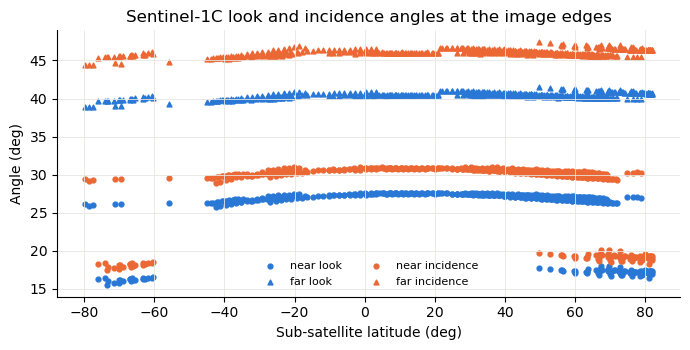

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for column, color in [("near look (deg)", BLUE), ("far look (deg)", BLUE), ("near incidence (deg)", ORANGE), ("far incidence (deg)", ORANGE)]:
    ax.scatter(geometry.latitude, geometry[column], s=12, color=color, marker="o" if "near" in column else "^", label=column.replace(" (deg)", ""))
ax.set(xlabel="Sub-satellite latitude (deg)", ylabel="Angle (deg)", title="Sentinel-1C look and incidence angles at the image edges")
ax.legend(frameon=False, fontsize=8, ncols=2)
fig.tight_layout()
plt.show()

All lines of sight fall to the right of the ground track and lie in the plane perpendicular to the Earth-fixed velocity (to within 0.002 deg): the images are in zero-Doppler geometry, which TAT-C's default Earth-fixed velocity frame reproduces. The inertial velocity frame would tilt the imaging plane by up to about 2.3 deg.

The IW mode images look angles from about 27.1 to 40.4 deg (median; incidence angles of 30.4 to 46.0 deg), a roll angle of 33.8 deg to the right and a cross-track field of view of 13.3 deg; the EW mode images 17.2 to 40.7 deg (incidence 19.1 to 46.4 deg), a roll angle of 29.0 deg and a field of view of 23.6 deg. The look angles vary smoothly with latitude by up to about 2.5 deg within each mode: Sentinel-1 steers its roll angle around the orbit to keep the slant range to the swath nearly constant as its altitude changes. A TAT-C `PointedInstrument` has a fixed roll angle, so the median look angles are used below.

## Test 3: Swath Edges

For each product, a TAT-C `PointedInstrument` is defined with its mode's roll angle and cross-track field of view (Test 2), negative for the right-looking radar. The rays at the near-range and far-range edges of its view (which TAT-C's rigid rotation places exactly at the edge look angles) are projected to the ellipsoid at the zero-Doppler times of every geolocation grid line and compared with the grid's near-range and far-range points, in both velocity frames. Residuals are decomposed along and to the right of the ground track (the horizontal direction of the reported Earth-fixed velocity) at each edge point.

In [7]:
rows3 = {}
for frame in [VelocityFrame.EARTH_FIXED, VelocityFrame.INERTIAL]:
    for edge, column in [("near", 0), ("far", -1)]:
        along_all, right_all = [], []
        for mode, m in zip(geometry["mode"], meta):
            look_angle = modes.loc[mode, f"{edge} look (deg)"]
            times = m["time"]
            _, velocity = interpolate_orbit(m, times)
            ray = compute_projected_ray_position(orbit.get_orbit_track(to_utc(times)), 0, 0, -look_angle, velocity_frame=frame)
            lon, lat = m["lon"][:, column], m["lat"][:, column]
            along, right = along_right(lon, lat, ecef(ray.longitude.degrees, ray.latitude.degrees) - ecef(lon, lat), velocity)
            along_all.append(along)
            right_all.append(right)
        rows3[(frame.value, edge, "along")] = summarize(np.concatenate(along_all))
        rows3[(frame.value, edge, "right")] = summarize(np.concatenate(right_all))
pd.DataFrame(rows3).T.round(2)

n  median  p95 |x|  max |x|
earth_fixed near along  5994.0    0.48     2.77     3.33
                 right  5994.0    0.07    14.10    23.83
            far  along  5994.0    0.50     2.84     3.40
                 right  5994.0    0.04    20.36    37.28
inertial    near along  5994.0    3.52    23.68    24.54
                 right  5994.0   -0.14    13.92    23.81
            far  along  5994.0    8.86    40.67    41.45
                 right  5994.0   -0.52    20.12    37.25

With the Earth-fixed velocity frame, TAT-C's view edges match the image edges to within about 3 km along track (95th percentile). Across track, they differ by up to 14 km at near range and 20 km at far range (95th percentile), the variation of the look angles from roll steering (Test 2). The inertial velocity frame displaces the edges by 24 to 41 km along track.

## Test 4: Frame Footprints

For every product acquired on the day, TAT-C's footprints from `compute_ground_track`, with its mode's roll angle and field of view, at time steps of about 5 s between the zero-Doppler times of its first and last grid lines (with the along-track field of view tailored to the time step, as in the imager notebooks), are merged and compared with the outline of its geolocation grid, in an azimuthal equidistant projection centered on the product.

In [8]:
TIME_STEP = 5  # s
ground_speed = 2 * np.pi * 6371.0088e3 / (86400 / float(TLE[1][52:63]))
altitude = float(np.median(geometry["altitude (km)"])) * 1e3


def sentinel1_view(mode, time_step=TIME_STEP, velocity_frame=VelocityFrame.EARTH_FIXED):
    """Rectangular, right-looking view of a Sentinel-1 mode, with the along-track field of view tailored to a time step (s)."""
    return PointedInstrument(
        name="Sentinel-1C C-SAR",
        field_of_regard=2 * (modes["far look (deg)"].max() + 1),
        cross_track_field_of_view=modes.loc[mode, "field of view (deg)"],
        along_track_field_of_view=np.degrees(2 * np.arctan(ground_speed * time_step / 2 / altitude)),
        roll_angle=-modes.loc[mode, "roll (deg)"],
        is_rectangular=True,
        velocity_frame=velocity_frame,
    )


def unwrap(geometry):
    """Shift longitudes of a polygon that crosses the antimeridian to be continuous."""
    lon = np.array(geometry.exterior.coords)[:, 0]
    if lon.max() - lon.min() > 180:
        return shapely.ops.transform(lambda x, y, z=None: (np.where(np.asarray(x) < 0, np.asarray(x) + 360, x), y), geometry)
    return geometry


def footprint_row(product):
    start, end = pd.Timestamp(product.zero_doppler_start, tz="UTC"), pd.Timestamp(product.zero_doppler_end, tz="UTC")
    n = max(1, int(round((end - start).total_seconds() / TIME_STEP)))
    step = (end - start) / n
    times = [(start + step * (i + 0.5)).floor("us").to_pydatetime() for i in range(n)]
    satellite = sentinel1.model_copy(update={"instruments": [sentinel1_view(product["mode"], step.total_seconds())]})
    predicted = compute_ground_track(satellite, times).geometry.iloc[0]
    observed = unwrap(shapely.force_2d(shapely.from_wkt(product.polygon)))
    center = observed.centroid
    project = Transformer.from_crs("EPSG:4326", f"+proj=aeqd +lat_0={center.y} +lon_0={center.x} +units=m", always_xy=True).transform
    a, b = transform_geometry(project, observed).buffer(0), transform_geometry(project, predicted).buffer(0)
    return {
        "granule": product.granule,
        "observed (km^2)": a.area / 1e6,
        "TAT-C (km^2)": b.area / 1e6,
        "IoU": a.intersection(b).area / a.union(b).area,
        "latitude": center.y,
    }


footprints = pd.DataFrame([footprint_row(product) for _, product in catalog.iterrows()]).merge(catalog[["granule", "mode", "direction"]])
pd.concat(
    [
        footprints[["IoU"]].describe(percentiles=[0.05, 0.5]).T.assign(group="all"),
        footprints.groupby("direction").IoU.describe(percentiles=[0.05, 0.5]).assign(group="direction"),
        footprints.groupby("mode").IoU.describe(percentiles=[0.05, 0.5]).assign(group="mode"),
    ]
).round(3)

,count,mean,std,min,5%,50%,max,group
IoU,499.0,0.923,0.032,0.757,0.874,0.927,0.981,all
ascending,225.0,0.921,0.036,0.757,0.857,0.925,0.980,direction
descending,274.0,0.925,0.029,0.787,0.881,0.928,0.981,direction
EW,97.0,0.952,0.031,0.854,0.894,0.964,0.981,mode
IW,402.0,0.916,0.028,0.757,0.865,0.925,0.961,mode


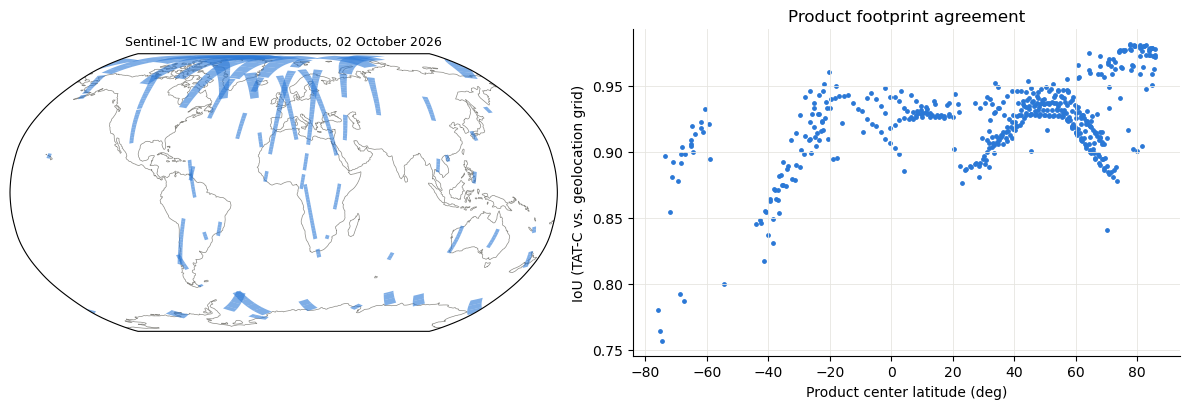

In [9]:
fig = plt.figure(figsize=(12, 4.2))
ax = fig.add_subplot(1, 2, 1, projection=ccrs.Robinson())
ax.set_global()
ax.coastlines(color=GRAY, linewidth=0.5)
for polygon in catalog.polygon:
    # split footprints that cross the antimeridian for plotting
    footprint = unwrap(shapely.force_2d(shapely.from_wkt(polygon)))
    parts = [footprint.intersection(shapely.box(-180, -90, 180, 90)), shapely.affinity.translate(footprint.intersection(shapely.box(180, -90, 540, 90)), -360)]
    ax.add_geometries([part for part in parts if not part.is_empty], crs=ccrs.PlateCarree(), facecolor=BLUE, edgecolor="none", alpha=0.6)
ax.set_title(f"Sentinel-1C IW and EW products, {DAY:%d %B %Y}", fontsize=9)
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(footprints.latitude, footprints.IoU, s=6, color=BLUE)
ax2.set(xlabel="Product center latitude (deg)", ylabel="IoU (TAT-C vs. geolocation grid)", title="Product footprint agreement")
fig.tight_layout()
plt.show()

TAT-C reproduces the product footprints with an IoU of 0.93 (median) for IW and 0.96 for EW products. The agreement follows the roll steering: it is best where the look angles are near their medians and worst at high southern latitudes, where the IW look angles are about 1.5 deg smaller.

## Test 5: Observation Times

Each geolocation grid point is a ground point with a known zero-Doppler time: the time at which Sentinel-1C imaged it. For interior grid points of every tenth product (excluding the outer 10% of the slant range extent and the first and last grid lines), `collect_observations` is run over a window of 10 minutes around the zero-Doppler time with the product's mode's `PointedInstrument` in each velocity frame, and the observation epoch nearest the zero-Doppler time is compared with it.

In [10]:
rows5 = {}
for frame in [VelocityFrame.EARTH_FIXED, VelocityFrame.INERTIAL]:
    differences, missed = [], 0
    for mode, m in zip(geometry["mode"][::10], meta[::10]):
        satellite = sentinel1.model_copy(update={"instruments": [sentinel1_view(mode, velocity_frame=frame)]})
        for i in np.linspace(1, len(m["time"]) - 2, 3).astype(int):
            for j in (np.linspace(0.1, 0.9, 5) * (len(m["slant_range"]) - 1)).round().astype(int):
                point = Point(id=0, latitude=float(m["lat"][i, j]), longitude=float(m["lon"][i, j]))
                truth = DAY + timedelta(seconds=float(m["time"][i]))
                observations = collect_observations(point, satellite, truth - timedelta(minutes=5), truth + timedelta(minutes=5))
                if observations.empty:
                    missed += 1
                    continue
                seconds = (observations.epoch - pd.Timestamp(truth)).dt.total_seconds().to_numpy()
                differences.append(seconds[np.argmin(np.abs(seconds))])
    rows5[frame.value] = pd.concat([pd.Series({"points": len(differences) + missed, "missed": missed}), summarize(differences).drop("n")])
pd.DataFrame(rows5).T.rename(columns={"median": "time, median (s)", "p95 |x|": "time, p95 |x| (s)", "max |x|": "time, max |x| (s)"}).round(3)

,points,missed,"time, median (s)","time, p95 |x| (s)","time, max |x| (s)"
earth_fixed,750.0,0.0,-0.068,0.439,0.495
inertial,750.0,0.0,-0.974,5.236,5.785


With the Earth-fixed velocity frame, `collect_observations` reports each point's observation epoch within 0.44 s of its zero-Doppler time (95th percentile) and observes every point. The inertial velocity frame shifts the epochs by up to about 6 s.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (CelesTrak TLE vs. restituted orbit) | 0.9 km along track (95th percentile) over the day |
| 2. Imaging geometry | right-looking; images in the plane perpendicular to the *Earth-fixed* velocity (inertial: up to 2.3 deg); IW roll 33.8 deg and field of view 13.3 deg, EW 29.0 and 23.6 deg; roll steering varies look angles by up to 2.5 deg |
| 3. Swath edges | 3 km along track and 14 to 20 km across track (95th percentile) with the Earth-fixed frame; 24 to 41 km along track with the inertial frame |
| 4. Product footprints (`compute_ground_track`) | IoU 0.93 (IW) and 0.96 (EW), median, for all 499 products |
| 5. Observation times (`collect_observations`) | 0.44 s (95th percentile) with the Earth-fixed frame; up to 6 s with the inertial frame |

**Velocity frame.** As for NISAR, Sentinel-1's zero-Doppler images lie in the plane perpendicular to the Earth-fixed velocity, which TAT-C's default `VelocityFrame.EARTH_FIXED` reproduces; the inertial frame would displace swath edges by up to 41 km along track and observation times by up to 6 s.

**Roll steering.** A right-looking `PointedInstrument` with a negative roll angle and rigid rotation reproduces Sentinel-1C's swath geometry, with per-mode parameters. Sentinel-1 steers its roll angle with latitude, so its look angles vary by up to 2.5 deg around the orbit; a fixed roll angle and field of view, set to the median look angles, misplace the swath edges by up to about 20 km (95th percentile) where the look angles depart most from the median. Modeling this would require a roll angle that varies around the orbit, which TAT-C does not support.